In [5]:
import evlicious
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import tqdm
import numpy as np
import os


dataset = "/home/pellerito/storage_pellerito_link/TartanEvent/abandonedfactory_night/Hard/P014"
image_files = sorted(Path(dataset + "/image_left").glob("*.png"))

events_file = dataset + "/events.h5"
indices_file = dataset + "/indices.txt"
os.mkdir("/home/pellerito/Automatic_dataset_conversion/plots")

# Plotting events on top

0it [00:00, ?it/s]

460it [01:22,  5.57it/s]


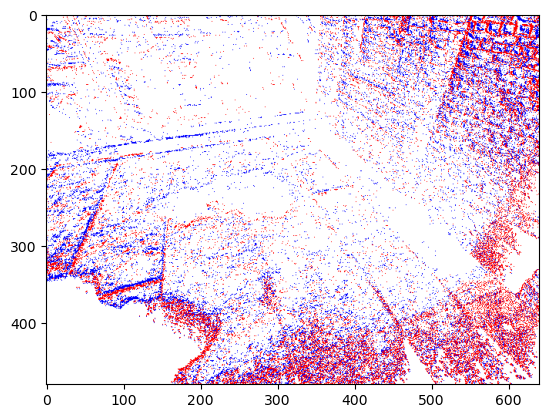

In [6]:
events = evlicious.io.load_events_from_path(Path(events_file))
i0, i1 = np.loadtxt(indices_file, delimiter=",").astype(int)

for num, image_ in tqdm.tqdm(enumerate(image_files)):
    plt.clf()
    image = cv2.imread(str(image_))
    # i_start = i0[num]
    i_stop = i1[num]
    i_start = i_stop-100000
    i_start = 0 if i_start < 0 else i_start
    new_events = events.get_between_idx(i_start, i_stop)
    # rendered = new_events.render(image)
    rendered = new_events.render(np.ones_like(image)*255)
    plt.imshow(rendered)
    plt.savefig("/home/pellerito/Automatic_dataset_conversion/plots/rendered_{:05d}.png".format(num))
